# Noise2Noise for Astrophotography Denoising

Train a U-Net to denoise galaxy images **without clean ground truth**, following Lehtinen et al. (2018), *Noise2Noise: Learning Image Restoration without Clean Data* ([arXiv:1803.04189](https://arxiv.org/abs/1803.04189)).

**Key idea.** If we have two independent noisy observations of the same scene, training a network to map one to the other minimizes the same expected loss as training against clean targets — provided the noise is zero-mean. This perfectly matches the astrophotography setting where multiple noisy exposures of a galaxy are easy, but clean references don't exist.

**Setup**
- **Dataset**: Galaxy10 DECaLS (~17k labeled galaxy images, 256×256 RGB)
- **Noise model**: synthetic Gaussian + Poisson, fresh noise sample per epoch → independent pairs
- **Model**: U-Net (encoder-decoder with skip connections, ~7.7M params at `base=32`)
- **Loss**: L2 (matches the N2N theoretical guarantee for Gaussian noise; L1 also works)
- **Runtime**: Colab free-tier friendly — 128×128 random crops, small batch, mixed precision on GPU

Open in Colab → Runtime → Change runtime type → **GPU (T4)**.

## 1. Setup

In [11]:
!pip install -q astroNN h5py astropy bm3d imageio

import os, math, time, random, io
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
import imageio.v2 as imageio

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)
if DEVICE == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

DOCS = Path('docs'); DOCS.mkdir(exist_ok=True)
FRAMES = Path('docs/_frames'); FRAMES.mkdir(exist_ok=True)

Device: cuda
GPU: Tesla T4


## 2. Configuration

In [12]:
class CFG:
    # Data
    n_images   = 8000    # full Galaxy10 DECaLS (use 4000 for fast iteration)
    crop_size  = 128
    val_frac   = 0.1

    # Noise (applied independently to each member of a pair)
    gauss_sigma = 25/255
    poisson_lam = 30.0

    # Model
    base_filters = 32
    depth        = 4

    # Training
    batch_size  = 16
    epochs      = 50
    lr          = 1e-3
    num_workers = 2

    # Training-GIF capture
    save_frames = True

cfg = CFG()

## 3. Dataset — Galaxy10 DECaLS

We use Galaxy10 DECaLS (17,736 labeled galaxy images). The images are already reasonably clean → we treat them as our latent *signal* and synthesize two independent noisy versions on the fly. This is the experimental setup from §3 of the N2N paper.

In [13]:
from astroNN.datasets import load_galaxy10

images, _labels = load_galaxy10()   # uint8, (N, 256, 256, 3)
print('Loaded:', images.shape, images.dtype)

# Keep uint8 to fit in Colab RAM (full set as float32 would be ~14 GB).
# Conversion to float32 happens lazily inside the Dataset.
idx = np.random.RandomState(SEED).permutation(len(images))[:cfg.n_images]
images = np.ascontiguousarray(images[idx])
print(f'Subset: {images.shape}  ({images.nbytes/1e9:.2f} GB in RAM)')

/root/.astroNN/datasets/Galaxy10_DECals.h5 was found!
Loaded: (17736, 256, 256, 3) uint8
Subset: (8000, 256, 256, 3)  (1.57 GB in RAM)


In [14]:
def add_noise(x: torch.Tensor) -> torch.Tensor:
    """Mixed Poisson-Gaussian noise. Zero-mean as required by N2N theory."""
    shot = torch.randn_like(x) * torch.sqrt(torch.clamp(x, min=0) / cfg.poisson_lam)
    read = torch.randn_like(x) * cfg.gauss_sigma
    return torch.clamp(x + shot + read, 0.0, 1.0)


class Galaxy10N2N(Dataset):
    """Returns (noisy_input, noisy_target, clean). The two noisy views are
    independent noise realizations of the same underlying patch.
    Images stored as uint8 to keep RAM bounded; converted to float in __getitem__."""

    def __init__(self, images: np.ndarray, crop: int, train: bool = True):
        self.images = images   # uint8, (N, H, W, 3)
        self.crop = crop
        self.train = train

    def __len__(self):
        return len(self.images)

    def __getitem__(self, i):
        img = self.images[i]
        H, W, _ = img.shape
        c = self.crop
        if self.train:
            y = random.randint(0, H - c); x = random.randint(0, W - c)
        else:
            y = (H - c) // 2; x = (W - c) // 2
        patch = img[y:y+c, x:x+c]
        patch = torch.from_numpy(patch).permute(2, 0, 1).contiguous().float() / 255.0

        if self.train and random.random() < 0.5:
            patch = torch.flip(patch, dims=[-1])

        noisy_in  = add_noise(patch)
        noisy_tgt = add_noise(patch)
        return noisy_in, noisy_tgt, patch


n_val = int(len(images) * cfg.val_frac)
train_imgs, val_imgs = images[n_val:], images[:n_val]
train_ds = Galaxy10N2N(train_imgs, cfg.crop_size, train=True)
val_ds   = Galaxy10N2N(val_imgs,   cfg.crop_size, train=False)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                          num_workers=cfg.num_workers, pin_memory=(DEVICE=='cuda'))
val_loader   = DataLoader(val_ds,   batch_size=cfg.batch_size, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=(DEVICE=='cuda'))

print(f'Train: {len(train_ds)} | Val: {len(val_ds)}')

Train: 7200 | Val: 800


### Sanity check — visualize a noisy pair

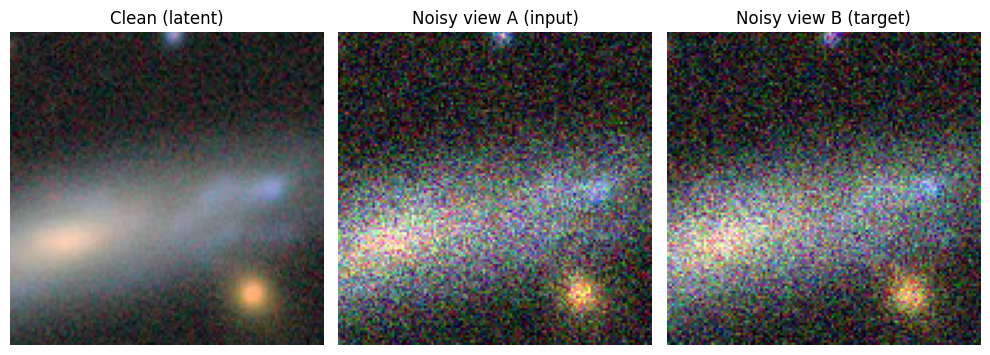

In [15]:
noisy_a, noisy_b, clean = next(iter(train_loader))

def show(t):
    return t.permute(1, 2, 0).clamp(0, 1).cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
axes[0].imshow(show(clean[0]));   axes[0].set_title('Clean (latent)')
axes[1].imshow(show(noisy_a[0])); axes[1].set_title('Noisy view A (input)')
axes[2].imshow(show(noisy_b[0])); axes[2].set_title('Noisy view B (target)')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.savefig(DOCS/'noisy_pair.png', dpi=140, bbox_inches='tight')
plt.show()

## 4. Model — U-Net

Standard encoder-decoder with skip connections. Outputs the denoised image directly (no residual), passed through `sigmoid` to stay in [0, 1].

In [16]:
class DoubleConv(nn.Module):
    def __init__(self, c_in, c_out):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(c_in, c_out, 3, padding=1, bias=False),
            nn.BatchNorm2d(c_out), nn.ReLU(inplace=True),
            nn.Conv2d(c_out, c_out, 3, padding=1, bias=False),
            nn.BatchNorm2d(c_out), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)


class UNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=3, base=32, depth=4):
        super().__init__()
        self.depth = depth
        self.encs = nn.ModuleList(); self.pools = nn.ModuleList()
        ch = in_ch
        for i in range(depth):
            o = base * (2 ** i)
            self.encs.append(DoubleConv(ch, o))
            self.pools.append(nn.MaxPool2d(2))
            ch = o
        self.bottleneck = DoubleConv(ch, base * (2 ** depth))
        ch = base * (2 ** depth)
        self.ups = nn.ModuleList(); self.decs = nn.ModuleList()
        for i in reversed(range(depth)):
            skip = base * (2 ** i)
            self.ups.append(nn.ConvTranspose2d(ch, skip, 2, 2))
            self.decs.append(DoubleConv(skip * 2, skip))
            ch = skip
        self.head = nn.Conv2d(ch, out_ch, 1)

    def forward(self, x):
        skips = []
        for e, p in zip(self.encs, self.pools):
            x = e(x); skips.append(x); x = p(x)
        x = self.bottleneck(x)
        for u, d, s in zip(self.ups, self.decs, reversed(skips)):
            x = u(x)
            if x.shape[-2:] != s.shape[-2:]:
                x = F.interpolate(x, size=s.shape[-2:], mode='bilinear', align_corners=False)
            x = d(torch.cat([s, x], dim=1))
        return torch.sigmoid(self.head(x))


model = UNet(base=cfg.base_filters, depth=cfg.depth).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f'U-Net parameters: {n_params/1e6:.2f}M')

U-Net parameters: 7.76M


## 5. Metrics

In [17]:
def psnr(pred: torch.Tensor, target: torch.Tensor) -> float:
    """Peak Signal-to-Noise Ratio in dB. Inputs assumed in [0, 1]."""
    mse = F.mse_loss(pred.clamp(0, 1), target).item()
    return 99.0 if mse == 0 else 10 * math.log10(1.0 / mse)


def _gaussian_window(window_size: int = 11, sigma: float = 1.5, channels: int = 3) -> torch.Tensor:
    coords = torch.arange(window_size, dtype=torch.float32) - window_size // 2
    g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    g = (g / g.sum()).unsqueeze(0)
    window = (g.T @ g).unsqueeze(0).unsqueeze(0)             # 1, 1, W, W
    return window.expand(channels, 1, window_size, window_size).contiguous()


def ssim(pred: torch.Tensor, target: torch.Tensor,
         window_size: int = 11, C1: float = 0.01 ** 2, C2: float = 0.03 ** 2) -> float:
    """Structural Similarity (Wang et al. 2004). Accepts (C,H,W) or (B,C,H,W) in [0,1]."""
    if pred.dim() == 3: pred = pred.unsqueeze(0)
    if target.dim() == 3: target = target.unsqueeze(0)
    pred = pred.clamp(0, 1); target = target.clamp(0, 1)
    C = pred.size(1)
    win = _gaussian_window(window_size, channels=C).to(pred.device, pred.dtype)
    pad = window_size // 2

    mu_p = F.conv2d(pred,   win, padding=pad, groups=C)
    mu_t = F.conv2d(target, win, padding=pad, groups=C)
    mu_p2, mu_t2, mu_pt = mu_p * mu_p, mu_t * mu_t, mu_p * mu_t

    sigma_p2 = F.conv2d(pred * pred,   win, padding=pad, groups=C) - mu_p2
    sigma_t2 = F.conv2d(target * target, win, padding=pad, groups=C) - mu_t2
    sigma_pt = F.conv2d(pred * target, win, padding=pad, groups=C) - mu_pt

    num = (2 * mu_pt + C1) * (2 * sigma_pt + C2)
    den = (mu_p2 + mu_t2 + C1) * (sigma_p2 + sigma_t2 + C2)
    return (num / den).mean().item()

## 6. Training

The loss is computed between the network output (on `noisy_in`) and `noisy_tgt`. The clean image is *never* used for training — only for diagnostic PSNR.

In [18]:
opt = torch.optim.Adam(model.parameters(), lr=cfg.lr)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg.epochs)
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE=='cuda'))

history = {'train_loss': [], 'val_loss': [],
           'val_psnr_noisy': [], 'val_psnr_clean': [],
           'val_ssim_noisy': [], 'val_ssim_clean': []}

# Fix one val sample for the training-progress GIF
fixed_noisy, _, fixed_clean = next(iter(val_loader))
fixed_noisy = fixed_noisy[:1].to(DEVICE)
fixed_clean = fixed_clean[:1].to(DEVICE)

for epoch in range(1, cfg.epochs + 1):
    # --- train ---
    model.train(); t0 = time.time(); train_loss = 0.0
    for noisy_in, noisy_tgt, _ in train_loader:
        noisy_in  = noisy_in.to(DEVICE, non_blocking=True)
        noisy_tgt = noisy_tgt.to(DEVICE, non_blocking=True)
        opt.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=(DEVICE=='cuda')):
            pred = model(noisy_in)
            loss = F.mse_loss(pred, noisy_tgt)
        scaler.scale(loss).backward()
        scaler.step(opt); scaler.update()
        train_loss += loss.item() * noisy_in.size(0)
    train_loss /= len(train_ds)

    # --- validate ---
    model.eval()
    val_loss = 0.0
    val_psnr_noisy = val_psnr_clean = 0.0
    val_ssim_noisy = val_ssim_clean = 0.0
    n = 0
    with torch.no_grad():
        for noisy_in, noisy_tgt, clean in val_loader:
            noisy_in  = noisy_in.to(DEVICE); noisy_tgt = noisy_tgt.to(DEVICE); clean = clean.to(DEVICE)
            pred = model(noisy_in)
            bs = noisy_in.size(0)
            val_loss       += F.mse_loss(pred, noisy_tgt).item() * bs
            val_psnr_noisy += psnr(noisy_in, clean) * bs
            val_psnr_clean += psnr(pred, clean)     * bs
            val_ssim_noisy += ssim(noisy_in, clean) * bs
            val_ssim_clean += ssim(pred, clean)     * bs
            n += bs
    val_loss /= n
    val_psnr_noisy /= n; val_psnr_clean /= n
    val_ssim_noisy /= n; val_ssim_clean /= n
    sched.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_psnr_noisy'].append(val_psnr_noisy)
    history['val_psnr_clean'].append(val_psnr_clean)
    history['val_ssim_noisy'].append(val_ssim_noisy)
    history['val_ssim_clean'].append(val_ssim_clean)

    # --- capture progress frame ---
    if cfg.save_frames:
        with torch.no_grad():
            pred_fixed = model(fixed_noisy).cpu()[0]
        fig, axes = plt.subplots(1, 3, figsize=(9, 3.2))
        axes[0].imshow(show(fixed_noisy[0].cpu())); axes[0].set_title('Noisy input')
        axes[1].imshow(show(pred_fixed));            axes[1].set_title(f'Epoch {epoch:02d}  |  {val_psnr_clean:.2f} dB')
        axes[2].imshow(show(fixed_clean[0].cpu()));  axes[2].set_title('Clean reference')
        for ax in axes: ax.axis('off')
        plt.tight_layout()
        plt.savefig(FRAMES/f'frame_{epoch:03d}.png', dpi=110, bbox_inches='tight')
        plt.close(fig)

    print(f'[{epoch:02d}/{cfg.epochs}] train {train_loss:.4f} | val {val_loss:.4f} '
          f'| PSNR {val_psnr_noisy:5.2f}->{val_psnr_clean:5.2f} dB '
          f'| SSIM {val_ssim_noisy:.3f}->{val_ssim_clean:.3f} '
          f'| {time.time()-t0:.0f}s')

/tmp/ipykernel_2169/3275300196.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
/tmp/ipykernel_2169/3275300196.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


[01/50] train 0.0229 | val 0.0168 | PSNR 18.22->26.38 dB | SSIM 0.312->0.610 | 38s
[02/50] train 0.0159 | val 0.0167 | PSNR 18.22->26.45 dB | SSIM 0.312->0.619 | 28s
[03/50] train 0.0157 | val 0.0167 | PSNR 18.22->26.63 dB | SSIM 0.312->0.622 | 35s
[04/50] train 0.0157 | val 0.0168 | PSNR 18.22->26.29 dB | SSIM 0.312->0.632 | 29s
[05/50] train 0.0157 | val 0.0168 | PSNR 18.22->26.58 dB | SSIM 0.312->0.627 | 28s
[06/50] train 0.0156 | val 0.0167 | PSNR 18.22->26.52 dB | SSIM 0.312->0.634 | 29s
[07/50] train 0.0156 | val 0.0167 | PSNR 18.22->26.57 dB | SSIM 0.312->0.634 | 30s
[08/50] train 0.0156 | val 0.0166 | PSNR 18.22->26.83 dB | SSIM 0.312->0.633 | 30s
[09/50] train 0.0156 | val 0.0166 | PSNR 18.22->26.65 dB | SSIM 0.312->0.635 | 30s
[10/50] train 0.0156 | val 0.0167 | PSNR 18.22->26.70 dB | SSIM 0.312->0.636 | 29s
[11/50] train 0.0155 | val 0.0166 | PSNR 18.22->26.77 dB | SSIM 0.312->0.636 | 30s
[12/50] train 0.0156 | val 0.0166 | PSNR 18.22->26.77 dB | SSIM 0.312->0.636 | 29s
[13/

## 7. Qualitative results

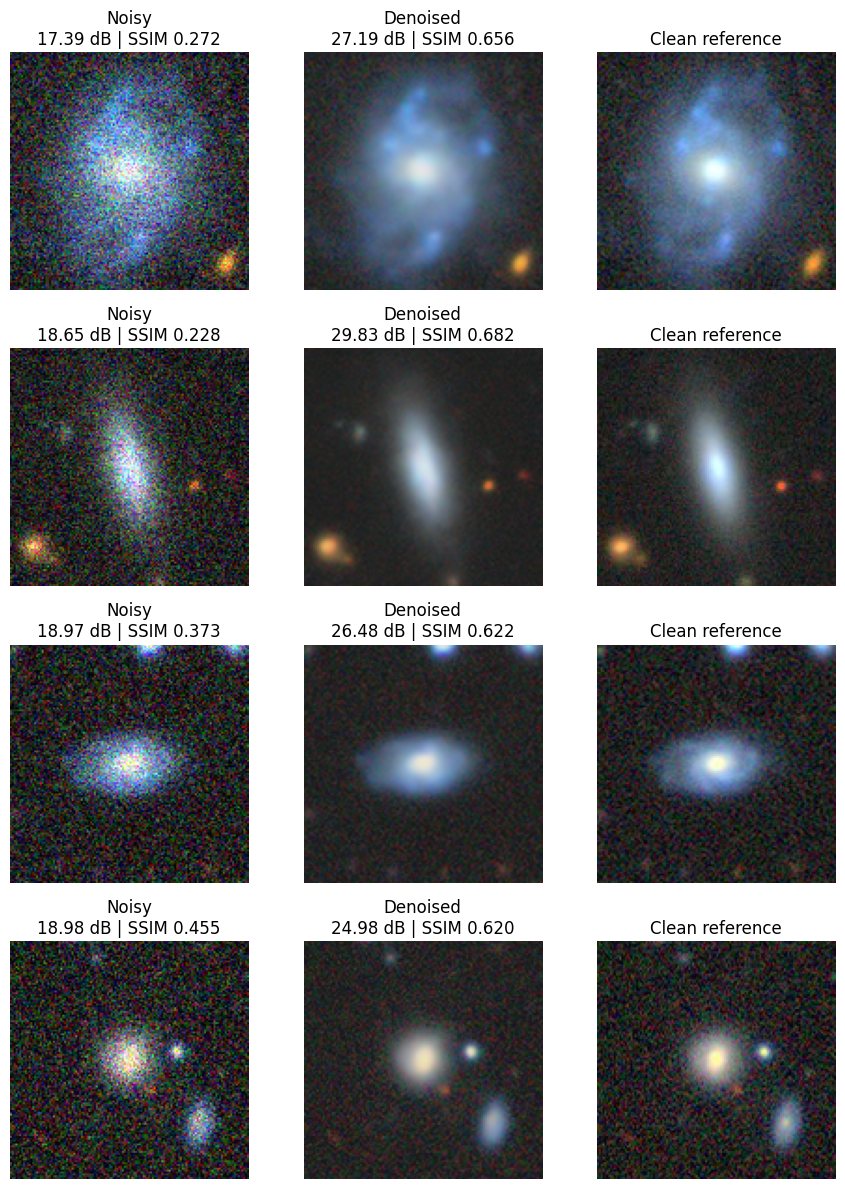

In [19]:
model.eval()
noisy_in, _, clean = next(iter(val_loader))
with torch.no_grad():
    pred = model(noisy_in.to(DEVICE)).cpu()

k = min(4, noisy_in.size(0))
fig, axes = plt.subplots(k, 3, figsize=(9, 3*k))
if k == 1: axes = axes[None, :]
for i in range(k):
    p_in,  s_in  = psnr(noisy_in[i], clean[i]), ssim(noisy_in[i], clean[i])
    p_out, s_out = psnr(pred[i],     clean[i]), ssim(pred[i],     clean[i])
    axes[i,0].imshow(show(noisy_in[i])); axes[i,0].set_title(f'Noisy\n{p_in:.2f} dB | SSIM {s_in:.3f}')
    axes[i,1].imshow(show(pred[i]));     axes[i,1].set_title(f'Denoised\n{p_out:.2f} dB | SSIM {s_out:.3f}')
    axes[i,2].imshow(show(clean[i]));    axes[i,2].set_title('Clean reference')
    for ax in axes[i]: ax.axis('off')
plt.tight_layout(); plt.show()

## 8. Curves

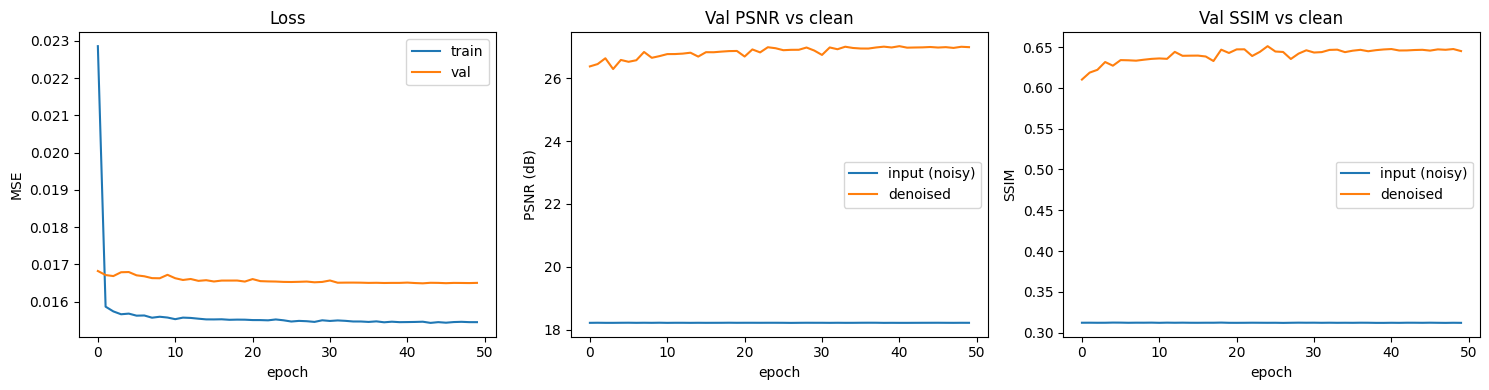

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history['train_loss'], label='train')
axes[0].plot(history['val_loss'], label='val')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('MSE'); axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(history['val_psnr_noisy'], label='input (noisy)')
axes[1].plot(history['val_psnr_clean'], label='denoised')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('PSNR (dB)'); axes[1].set_title('Val PSNR vs clean'); axes[1].legend()

axes[2].plot(history['val_ssim_noisy'], label='input (noisy)')
axes[2].plot(history['val_ssim_clean'], label='denoised')
axes[2].set_xlabel('epoch'); axes[2].set_ylabel('SSIM'); axes[2].set_title('Val SSIM vs clean'); axes[2].legend()

plt.tight_layout()
plt.savefig(DOCS/'curves.png', dpi=140, bbox_inches='tight')
plt.show()

## 9. Save weights

In [21]:
out = Path('unet_n2n_galaxy10.pt')
torch.save({'model': model.state_dict(), 'cfg': vars(cfg), 'history': history}, out)
print('Saved →', out.resolve())

# In Colab, download with:
from google.colab import files; files.download(str(out))

Saved → /content/unet_n2n_galaxy10.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 10. Try it on your own astrophoto

Upload any image (PNG / JPEG / TIFF). The model expects RGB in [0, 1]; it will be tiled if larger than ~1k px to keep VRAM bounded.

**Honest expectations.** The model was trained on Galaxy10 DECaLS with synthetic Poisson+Gaussian noise. On real amateur astrophotos it will:
- Work reasonably well on **single-galaxy subjects** with similar color stretch.
- Over-smooth **star fields and thin filaments** (it has never seen them).
- Possibly amplify or learn-around **hot pixels, amp glow, JPEG blocks** — those violate the zero-mean noise assumption.

If results look bad, that's expected — it's the natural lead-in to the "fine-tune on real pairs" next step.

Saving M101.jpg to M101 (1).jpg
Input shape: (3, 4168, 3840)


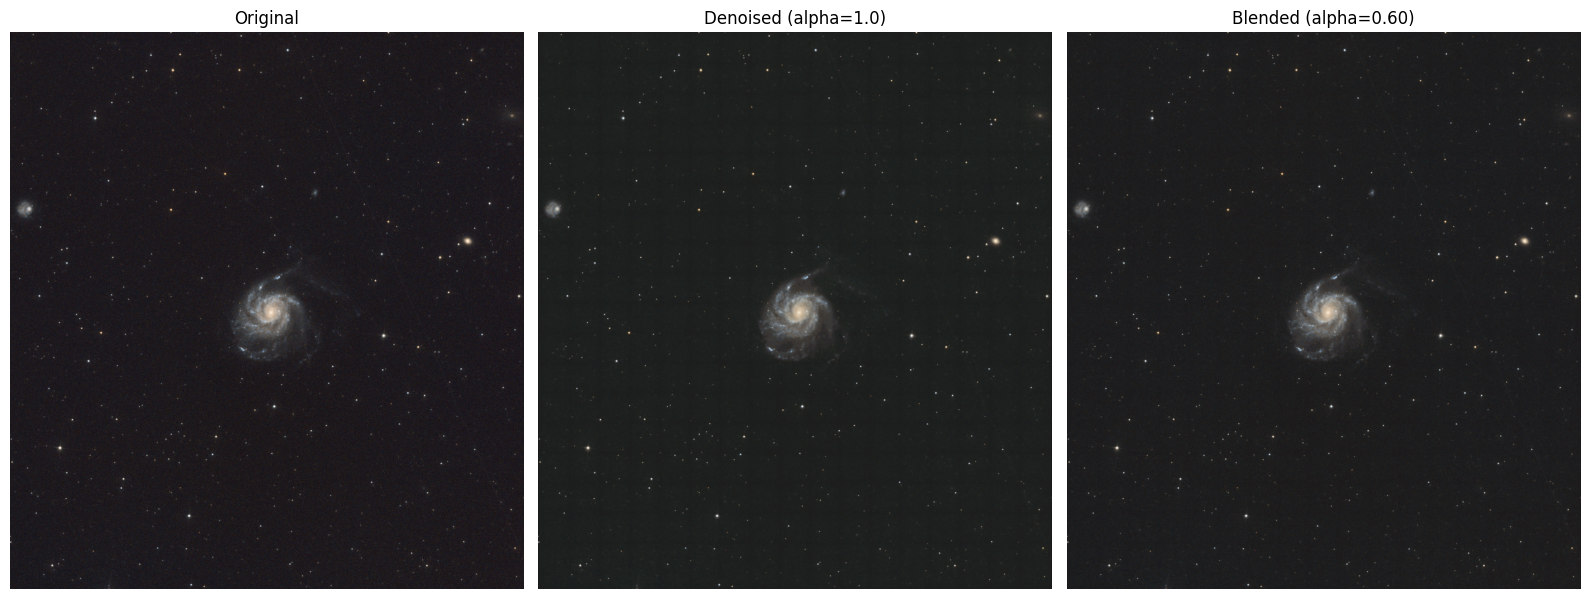

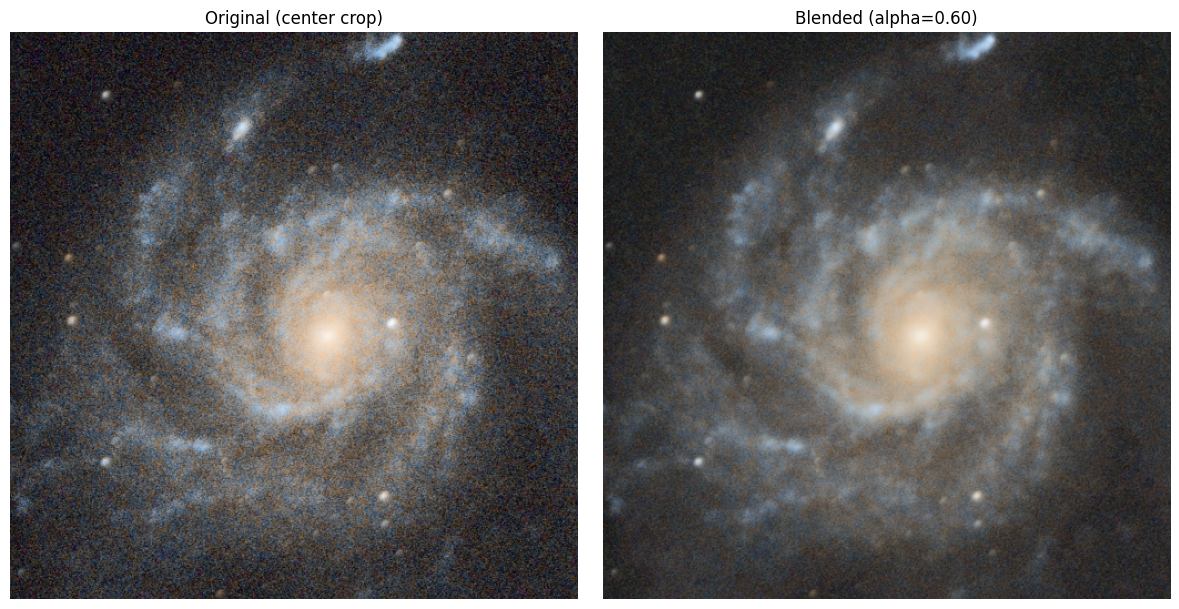

Saved -> /content/M101 (1)_denoised_a0.60.png


In [22]:
# --- Colab: upload an image ---
from google.colab import files
uploaded = files.upload()
image_path = next(iter(uploaded))

# --- Local / Colab with path ---
# image_path = 'my_astrophoto.jpg'   # PNG / JPG / TIFF / FITS

# --- Aggressiveness knob (0 = original, 1 = full denoise) ---
alpha = 0.6

from PIL import Image

def load_image(path: str) -> torch.Tensor:
    """Load PNG/JPEG/TIFF or FITS into an RGB tensor in [0, 1]."""
    p = Path(path)
    if p.suffix.lower() in {'.fits', '.fit', '.fts'}:
        from astropy.io import fits
        with fits.open(p) as hdul:
            data = next(h.data for h in hdul if h.data is not None).astype(np.float32)
        # Handle (H, W) or (C, H, W) or (H, W, C)
        if data.ndim == 2:
            data = np.stack([data]*3, axis=-1)        # grayscale -> RGB
        elif data.ndim == 3 and data.shape[0] in (1, 3, 4):
            data = np.moveaxis(data, 0, -1)
        if data.shape[-1] == 4:
            data = data[..., :3]                       # drop alpha
        # Robust per-channel normalize using 1st-99th percentiles
        lo, hi = np.percentile(data, [1, 99], axis=(0, 1), keepdims=True)
        data = np.clip((data - lo) / np.maximum(hi - lo, 1e-8), 0, 1).astype(np.float32)
        return torch.from_numpy(data).permute(2, 0, 1)
    img = Image.open(p).convert('RGB')
    arr = np.asarray(img, dtype=np.float32) / 255.0
    return torch.from_numpy(arr).permute(2, 0, 1)


@torch.no_grad()
def denoise_tiled(model, img: torch.Tensor, tile: int = 256, overlap: int = 32) -> torch.Tensor:
    """Tiled inference with triangular blend window."""
    model.eval()
    C, H, W = img.shape
    stride = tile - overlap
    pad_h = (16 - H % 16) % 16
    pad_w = (16 - W % 16) % 16
    img_p = F.pad(img.unsqueeze(0), (0, pad_w, 0, pad_h), mode='reflect').squeeze(0)
    Hp, Wp = img_p.shape[-2:]

    out    = torch.zeros_like(img_p)
    weight = torch.zeros_like(img_p)
    ramp = torch.ones(tile)
    if overlap > 0:
        r = torch.linspace(0, 1, overlap)
        ramp[:overlap] = r; ramp[-overlap:] = r.flip(0)
    win = ramp[:, None] * ramp[None, :]

    ys = list(range(0, max(1, Hp - tile + 1), stride))
    xs = list(range(0, max(1, Wp - tile + 1), stride))
    if ys[-1] + tile < Hp: ys.append(Hp - tile)
    if xs[-1] + tile < Wp: xs.append(Wp - tile)

    for y in ys:
        for x in xs:
            patch = img_p[:, y:y+tile, x:x+tile].unsqueeze(0).to(DEVICE)
            pred = model(patch).squeeze(0).cpu()
            out[:,    y:y+tile, x:x+tile] += pred * win
            weight[:, y:y+tile, x:x+tile] += win

    out = out / weight.clamp(min=1e-8)
    return out[:, :H, :W]


img = load_image(image_path)
print('Input shape:', tuple(img.shape))

denoised_full = denoise_tiled(model, img, tile=256, overlap=32)
denoised = (alpha * denoised_full + (1 - alpha) * img).clamp(0, 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
axes[0].imshow(show(img));            axes[0].set_title('Original')
axes[1].imshow(show(denoised_full));  axes[1].set_title('Denoised (alpha=1.0)')
axes[2].imshow(show(denoised));       axes[2].set_title(f'Blended (alpha={alpha:.2f})')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.savefig(DOCS/'real_astrophoto.png', dpi=140, bbox_inches='tight')
plt.show()

C, H, W = img.shape
ch, cw = min(512, H), min(512, W)
y0, x0 = (H - ch) // 2, (W - cw) // 2
crop = lambda t: t[:, y0:y0+ch, x0:x0+cw]
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(show(crop(img)));      axes[0].set_title('Original (center crop)')
axes[1].imshow(show(crop(denoised))); axes[1].set_title(f'Blended (alpha={alpha:.2f})')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

out_path = Path(image_path).with_name(f'{Path(image_path).stem}_denoised_a{alpha:.2f}.png')
Image.fromarray((show(denoised) * 255).clip(0, 255).astype(np.uint8)).save(out_path)
print('Saved ->', out_path.resolve())

## 11. Classical baseline — BM3D

Before claiming the network "denoises well," we should compare against a strong **non-learned** baseline. **BM3D** (Dabov et al. 2007) is the gold standard for classical Gaussian denoising — block matching + collaborative filtering. It needs no training and is what learned methods must beat to justify themselves.

In [23]:
from bm3d import bm3d_rgb

def to_np(t):
    return t.permute(1, 2, 0).clamp(0, 1).numpy().astype(np.float32)

def from_np(a):
    return torch.from_numpy(a).permute(2, 0, 1).float()

@torch.no_grad()
def eval_bm3d_vs_unet(val_loader, sigma=25/255, max_batches=8):
    """Compare BM3D and U-Net on the same val noisy inputs."""
    rows = []
    model.eval()
    for bi, (noisy_in, _, clean) in enumerate(val_loader):
        if bi >= max_batches: break
        unet_pred = model(noisy_in.to(DEVICE)).cpu()
        for i in range(noisy_in.size(0)):
            # BM3D (RGB, expects sigma in same units as input)
            bm3d_pred = from_np(bm3d_rgb(to_np(noisy_in[i]), sigma_psd=sigma))
            rows.append({
                'psnr_noisy':  psnr(noisy_in[i], clean[i]),
                'psnr_bm3d':   psnr(bm3d_pred,    clean[i]),
                'psnr_unet':   psnr(unet_pred[i], clean[i]),
                'ssim_noisy':  ssim(noisy_in[i], clean[i]),
                'ssim_bm3d':   ssim(bm3d_pred,    clean[i]),
                'ssim_unet':   ssim(unet_pred[i], clean[i]),
            })
    return rows

print('Running BM3D vs U-Net on a subset of the val set (this is CPU-slow)...')
rows = eval_bm3d_vs_unet(val_loader, sigma=cfg.gauss_sigma, max_batches=4)

def avg(rows, k): return sum(r[k] for r in rows) / len(rows)
print(f"\n{'method':<12} {'PSNR (dB)':>10} {'SSIM':>8}")
print('-' * 32)
print(f"{'noisy':<12} {avg(rows,'psnr_noisy'):>10.2f} {avg(rows,'ssim_noisy'):>8.3f}")
print(f"{'BM3D':<12} {avg(rows,'psnr_bm3d'):>10.2f} {avg(rows,'ssim_bm3d'):>8.3f}")
print(f"{'U-Net (N2N)':<12} {avg(rows,'psnr_unet'):>10.2f} {avg(rows,'ssim_unet'):>8.3f}")

Running BM3D vs U-Net on a subset of the val set (this is CPU-slow)...

method        PSNR (dB)     SSIM
--------------------------------
noisy             18.42    0.314
BM3D              24.43    0.479
U-Net (N2N)       27.19    0.641


## 12. Training-progress GIF

The frames saved each epoch by the training loop can be stitched into an animation. Useful as a `README` hero image.

In [24]:
frames = sorted(FRAMES.glob('frame_*.png'))
print(f'Found {len(frames)} frames.')

gif_path = DOCS / 'training_progress.gif'
imgs = [imageio.imread(f) for f in frames]
imageio.mimsave(gif_path, imgs, duration=0.2, loop=0)
print('Saved ->', gif_path.resolve())

Found 50 frames.
Saved -> /content/docs/training_progress.gif


## 13. Bonus — Noise2Void (single-image denoising)

What if you don't even have noisy *pairs*? **Noise2Void** (Krull et al., CVPR 2019) trains on individual noisy images by masking a few pixels per patch and asking the network to predict them from the surrounding noisy context. Because the model can't see the masked pixel's noise, it can only learn to predict the underlying signal.

This is a small modification of the same U-Net training loop — proof that the framework extends naturally.

[N2V 1/5] loss 0.0649 | 44s
[N2V 2/5] loss 0.0488 | 41s
[N2V 3/5] loss 0.0485 | 42s
[N2V 4/5] loss 0.0484 | 42s
[N2V 5/5] loss 0.0484 | 42s


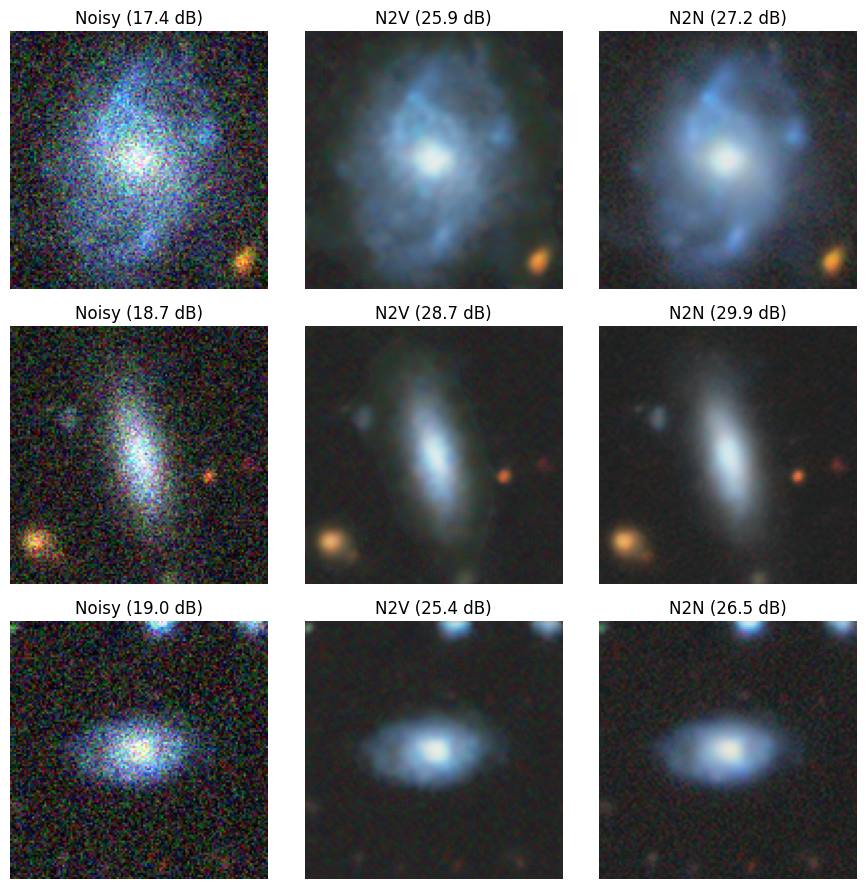

In [26]:
class Galaxy10N2V(Dataset):
    """Single-noisy-image dataset with blind-spot masking for N2V training."""
    def __init__(self, images, crop, n_masked=64):
        self.images = images; self.crop = crop; self.n_masked = n_masked

    def __len__(self): return len(self.images)

    def __getitem__(self, i):
        img = self.images[i]; H, W, _ = img.shape; c = self.crop
        y = random.randint(0, H - c); x = random.randint(0, W - c)
        patch = img[y:y+c, x:x+c]
        # uint8 -> float32 in [0,1] (mirrors Galaxy10N2N)
        patch = torch.from_numpy(patch).permute(2, 0, 1).contiguous().float() / 255.0
        noisy = add_noise(patch)

        # Blind-spot mask: replace each chosen pixel with a random neighbor's value.
        mask = torch.zeros(1, c, c)
        masked_input = noisy.clone()
        for _ in range(self.n_masked):
            py, px = random.randint(0, c-1), random.randint(0, c-1)
            ny = min(max(py + random.randint(-3, 3), 0), c-1)
            nx = min(max(px + random.randint(-3, 3), 0), c-1)
            masked_input[:, py, px] = noisy[:, ny, nx]
            mask[0, py, px] = 1.0
        return masked_input, noisy, mask


n2v_train = Galaxy10N2V(train_imgs, cfg.crop_size)
n2v_loader = DataLoader(n2v_train, batch_size=cfg.batch_size, shuffle=True,
                        num_workers=cfg.num_workers, pin_memory=(DEVICE=='cuda'))

model_n2v = UNet(base=cfg.base_filters, depth=cfg.depth).to(DEVICE)
opt_n2v = torch.optim.Adam(model_n2v.parameters(), lr=cfg.lr)

N2V_EPOCHS = 5
for epoch in range(1, N2V_EPOCHS + 1):
    model_n2v.train(); t0 = time.time(); loss_acc = 0.0
    for masked_in, noisy_full, mask in n2v_loader:
        masked_in = masked_in.to(DEVICE); noisy_full = noisy_full.to(DEVICE); mask = mask.to(DEVICE)
        pred = model_n2v(masked_in)
        loss = ((pred - noisy_full) ** 2 * mask).sum() / mask.sum().clamp(min=1)
        opt_n2v.zero_grad(set_to_none=True); loss.backward(); opt_n2v.step()
        loss_acc += loss.item() * masked_in.size(0)
    print(f'[N2V {epoch}/{N2V_EPOCHS}] loss {loss_acc/len(n2v_train):.4f} | {time.time()-t0:.0f}s')

model_n2v.eval()
noisy_in, _, clean = next(iter(val_loader))
with torch.no_grad():
    pred_n2v = model_n2v(noisy_in.to(DEVICE)).cpu()
    pred_n2n = model(noisy_in.to(DEVICE)).cpu()

fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for i in range(3):
    axes[i,0].imshow(show(noisy_in[i])); axes[i,0].set_title(f'Noisy ({psnr(noisy_in[i], clean[i]):.1f} dB)')
    axes[i,1].imshow(show(pred_n2v[i])); axes[i,1].set_title(f'N2V ({psnr(pred_n2v[i], clean[i]):.1f} dB)')
    axes[i,2].imshow(show(pred_n2n[i])); axes[i,2].set_title(f'N2N ({psnr(pred_n2n[i], clean[i]):.1f} dB)')
    for ax in axes[i]: ax.axis('off')
plt.tight_layout()
plt.savefig(DOCS/'n2v_vs_n2n.png', dpi=140, bbox_inches='tight')
plt.show()